In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
# 1. Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Normalize pixel values (0-255 → 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

In [3]:
# 3. Build Neural Network model
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),   # convert 28x28 image to 1D
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 digits (0–9)
])

C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
# 4. Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [5]:
# 5. Train model
model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# 6. Evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

# 7. Predict digits
predictions = model.predict(x_test)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9244 - loss: 0.2529 - val_accuracy: 0.9645 - val_loss: 0.1144
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9677 - loss: 0.1055 - val_accuracy: 0.9737 - val_loss: 0.0885
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9769 - loss: 0.0731 - val_accuracy: 0.9750 - val_loss: 0.0836
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9825 - loss: 0.0538 - val_accuracy: 0.9777 - val_loss: 0.0793
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9854 - loss: 0.0450 - val_accuracy: 0.9788 - val_loss: 0.0746
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9769 - loss: 0.0771
Test accuracy: 0.9768999814987183
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


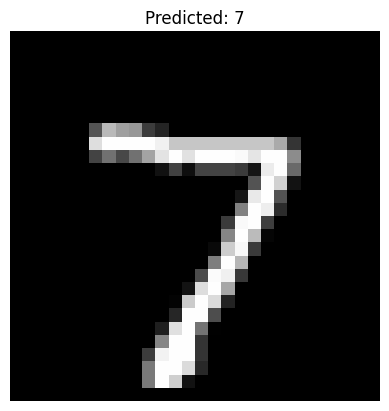

In [6]:
# 8. Show prediction example
plt.imshow(x_test[0], cmap='gray')
plt.title(f"Predicted: {predictions[0].argmax()}")
plt.axis('off')
plt.show()